---
tags:
  - transient
  - matrix-free
---

# Heat Transfer in a Plate with a Hole

This notebook demonstrates how to solve a transient heat transfer problem using `tatva`. We consider a plate with a circular hole, where temperature boundary conditions are applied to the top and bottom edges. The problem is solved using the Finite Element Method (FEM) with a matrix-free approach and an implicit time-stepping scheme.


### Governing Equation
The transient heat conduction is governed by the heat equation:

$$
\rho c_p \frac{\partial T}{\partial t} - \nabla \cdot (k \nabla T) = q
$$

where:
- $T$ is the temperature field,
- $\rho$ is the density,
- $c_p$ is the specific heat capacity,
- $k$ is the thermal conductivity,
- $q$ is the internal heat source (assumed zero here).

### Energy Formulation
In `tatva`, we define the problem using an energy-centric approach. We define energy functionals for the stiffness and mass (storage) parts. 

The **Thermal Energy** (stiffness) representing steady-state conduction is:

$$
\Psi_{th}(T) = \int_{\Omega} \frac{1}{2} k |\nabla T|^2 \, \mathrm{d}\Omega
$$

The **Mass Energy** (storage) representing heat capacity is:

$$
\Psi_{m}(T) = \int_{\Omega} \frac{1}{2} \rho c_p T^2 \, \mathrm{d}\Omega
$$

The internal "forces" (thermal and inertial) are obtained by taking the derivative of these energies with respect to the temperature field $T$. Specifically, the stiffness force is $\mathbf{f}_{th} = \frac{\partial \Psi_{th}}{\partial \mathbf{T}}$ and the mass force is $\mathbf{f}_{m} = \frac{\partial \Psi_{m}}{\partial \mathbf{T}}$.

### Time Discretization
We use the **Implicit Euler** scheme for time discretization. For a time step $\Delta t$, the equilibrium at step $n+1$ is reached when the residual is zero:

$$
\frac{\mathbf{M}(\mathbf{T}_{n+1} - \mathbf{T}_n)}{\Delta t} + \mathbf{K} \mathbf{T}_{n+1} = 0
$$

where $\mathbf{M}$ and $\mathbf{K}$ are the mass and stiffness matrices (Hessians of the energy functionals). Rearranging for the increment $\Delta \mathbf{T} = \mathbf{T}_{n+1} - \mathbf{T}_n$:

$$
(\mathbf{M} + \Delta t \mathbf{K}) \Delta \mathbf{T} = - \Delta t \mathbf{K} \mathbf{T}_n
$$

Instead of assembling these matrices explicitly, we use JAX's Automatic Differentiation (AD) to compute Jacobian-vector products, enabling a **matrix-free** solver using the Conjugate Gradient (CG) method.

In [ ]:
# [collapse: code] Colab Setup (Install Dependencies)

# Only run this if we are in Google Colab
if 'google.colab' in str(get_ipython()):
    print("Installing dependencies using uv...")
    !pip install -q uv
    !apt-get install -qq gmsh
    !uv pip install --system matplotlib meshio equinox
    !uv pip install --system "git+https://github.com/smec-ethz/tatva-docs.git"
    print("Installation complete!")

In [1]:
import os
import time
from typing import Callable

import equinox as eqx
import gmsh
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import meshio
import numpy as np
from jax import Array
from jax_autovmap import autovmap
from matplotlib.axes import Axes
from tatva import Mesh, Operator, element

jax.config.update("jax_enable_x64", True)

In [2]:
# [collapse: code] Code for generating a refined plate with a hole and plotting the mesh

def plot_mesh(mesh: Mesh, ax: Axes | None = None) -> None:
    if ax is None:
        fig, ax = plt.subplots()
    ax.tripcolor(
        mesh.coords[:, 0],
        mesh.coords[:, 1],
        mesh.elements,
        facecolors=np.ones(len(mesh.elements)),
        cmap="managua",
        edgecolors="k",
        linewidth=0.2,
    )
    ax.set_aspect("equal")

def generate_refined_plate_with_hole(
    width: float,
    height: float,
    hole_radius: float,
    mesh_size_fine: float,
    mesh_size_coarse: float,
):
    mesh_dir = os.path.join(os.getcwd(), "meshes")
    os.makedirs(mesh_dir, exist_ok=True)
    output_filename = os.path.join(mesh_dir, "plate_hole_refined.msh")

    gmsh.initialize()
    gmsh.model.add("plate_with_hole_refined")
    occ = gmsh.model.occ

    rect = occ.addRectangle(0, 0, 0, width, height)
    cx = width / 2.0
    cy = height / 2.0
    disk = occ.addDisk(cx, cy, 0, hole_radius, hole_radius)

    out, _ = occ.cut([(2, rect)], [(2, disk)])
    occ.synchronize()

    surface_tag = out[0][1]
    gmsh.model.addPhysicalGroup(2, [surface_tag], 1, name="domain")

    boundaries = gmsh.model.getBoundary(out, oriented=False)
    boundary_tags = [b[1] for b in boundaries]
    gmsh.model.addPhysicalGroup(1, boundary_tags, 2, name="boundaries")

    hole_curve_tags = []
    for tag in boundary_tags:
        xmin, ymin, zmin, xmax, ymax, zmax = gmsh.model.getBoundingBox(1, tag)
        if xmin > 0 and xmax < width and ymin > 0 and ymax < height:
            hole_curve_tags.append(tag)

    gmsh.model.mesh.field.add("Distance", 1)
    gmsh.model.mesh.field.setNumbers(1, "CurvesList", hole_curve_tags)
    gmsh.model.mesh.field.setNumber(1, "NumPointsPerCurve", 100)

    gmsh.model.mesh.field.add("Threshold", 2)
    gmsh.model.mesh.field.setNumber(2, "InField", 1)
    gmsh.model.mesh.field.setNumber(2, "SizeMin", mesh_size_fine)
    gmsh.model.mesh.field.setNumber(2, "SizeMax", mesh_size_coarse)
    gmsh.model.mesh.field.setNumber(2, "DistMin", 0.0)
    gmsh.model.mesh.field.setNumber(2, "DistMax", hole_radius * 2.0)

    gmsh.model.mesh.field.setAsBackgroundMesh(2)
    gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 0)
    gmsh.option.setNumber("Mesh.MeshSizeFromPoints", 0)
    gmsh.option.setNumber("Mesh.MeshSizeFromCurvature", 0)

    gmsh.model.mesh.generate(2)
    gmsh.write(output_filename)
    gmsh.finalize()

    _mesh = meshio.read(output_filename)
    coords = _mesh.points[:, :2]
    elements = _mesh.cells_dict["triangle"]

    return Mesh(coords=coords, elements=elements)

Info    : Meshing 1D...                                                                                                                        
Info    : [  0%] Meshing curve 5 (Ellipse)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 50%] Meshing curve 7 (Line)
Info    : [ 70%] Meshing curve 8 (Line)
Info    : [ 90%] Meshing curve 9 (Line)
Info    : Done meshing 1D (Wall 0.0323048s, CPU 0.032675s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.168509s, CPU 0.166183s)
Info    : 5689 nodes 11383 elements
Info    : Writing '/home/mohit/Documents/dev/tatva-docs/notebooks/examples/meshes/plate_hole_refined.msh'...
Info    : Done writing '/home/mohit/Documents/dev/tatva-docs/notebooks/examples/meshes/plate_hole_refined.msh'



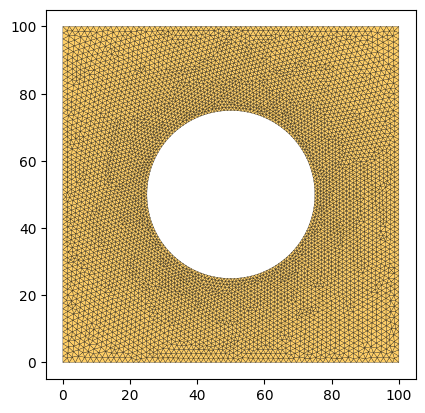

In [3]:
lx = ly = 100.0
radius = lx / 4.0
mesh = generate_refined_plate_with_hole(
    lx, ly, hole_radius=radius, mesh_size_fine=1.0, mesh_size_coarse=2.0
)

n_dofs = mesh.coords.shape[0]
plot_mesh(mesh)

## Physical Parameters and BCs

We define the material properties and the Dirichlet boundary conditions for the top and bottom edges.

In [4]:
k = 45e-3   # W/mm-K, thermal conductivity
rho = 7.8e-6 # kg/mm^3, density
cp = 496     # J/kg-K, specific heat capacity

T_top = 1.0
T_bottom = 0.1

op = Operator(mesh, element.Tri3())

top_nodes = jnp.where(jnp.isclose(mesh.coords[:, 1], ly, atol=1e-8))[0]
bottom_nodes = jnp.where(jnp.isclose(mesh.coords[:, 1], 0.0, atol=1e-8))[0]
fixed_dofs = jnp.concatenate([top_nodes, bottom_nodes])

## Variational Forms and Residuals

Instead of assembling matrices, we define energy densities corresponding to the stiffness and mass contributions. Their derivatives with respect to temperature will provide the internal and inertial forces.

In [5]:
@autovmap(grad_T=1)
def thermal_energy_density(grad_T: Array) -> Array:
    return 0.5 * k * jnp.dot(grad_T, grad_T)

@jax.jit
def total_thermal_energy(T_flat: Array) -> Array:
    grad_T = op.grad(T_flat)
    return op.integrate(thermal_energy_density(grad_T))

@autovmap(T=0)
def mass_energy_density(T: Array) -> Array:
    return 0.5 * rho * cp * T * T

@jax.jit
def total_mass_energy(T_flat: Array) -> Array:
    T_quad = op.eval(T_flat)
    return op.integrate(mass_energy_density(T_quad))

compute_stiffness_force = jax.jacrev(total_thermal_energy)
compute_mass_force = jax.jacrev(total_mass_energy)

## Matrix-Free Solver

We use the Conjugate Gradient (CG) method to solve the linear system $(M + \Delta t K) \Delta T = \Delta t (F_{ext} - K T_n)$ at each time step. The action of the matrix is computed using JAX's `jvp` (Jacobian-Vector Product).

In [6]:
@jax.jit
def K_times_x(T_prev: Array, dT: Array) -> Array:
    dT_p = dT.at[fixed_dofs].set(0.0)
    tangent = jax.jvp(compute_stiffness_force, (T_prev,), (dT_p,))[1]
    return tangent.at[fixed_dofs].set(0.0)

@jax.jit
def M_times_x(T_prev: Array, dT: Array) -> Array:
    dT_p = dT.at[fixed_dofs].set(0.0)
    tangent = jax.jvp(compute_mass_force, (T_prev,), (dT_p,))[1]
    return tangent.at[fixed_dofs].set(0.0)

@jax.jit
def A_times_x(dT: Array, T_prev: Array, dt: float) -> Array:
    return M_times_x(T_prev, dT) + dt * K_times_x(T_prev, dT)

@eqx.filter_jit
def conjugate_gradient(A: Callable, b: Array, atol=1e-8, max_iter=500):
    x = jnp.zeros_like(b)
    r = b - A(x)
    p = r
    rsold = jnp.vdot(r, r)
    iiter = 0

    def cond_fun(state):
        _, _, _, rsold, _, iiter = state
        return jnp.logical_and(jnp.sqrt(rsold) > atol, iiter < max_iter)

    def body_fun(state):
        b, p, r, rsold, x, iiter = state
        Ap = A(p)
        alpha = rsold / jnp.vdot(p, Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rsnew = jnp.vdot(r, r)
        p = r + (rsnew / rsold) * p
        return b, p, r, rsnew, x, iiter + 1

    _, _, _, _, x, iiter = jax.lax.while_loop(
        cond_fun, body_fun, (b, p, r, rsold, x, iiter)
    )
    return x, iiter

## Transient Simulation Loop

The initial condition is $T=0$ everywhere in the plate. We run simulation for a total of 200 sec with a $\Delta t=1$ sec.

In [7]:
# Initial condition: T=0 everywhere except at boundaries
T_init = jnp.zeros(n_dofs)
T_init = T_init.at[top_nodes].set(T_top)
T_init = T_init.at[bottom_nodes].set(T_bottom)

total_time = 200.0
dt = 1.0
n_steps = int(total_time / dt)
save_interval = 10

f_ext = jnp.zeros(n_dofs)
T_curr = T_init
T_history = [T_curr]

print(f"Running {n_steps} steps...")
t_start = time.perf_counter()

for step in range(n_steps):
    fint = compute_stiffness_force(T_curr)
    rhs = (f_ext - fint) * dt
    rhs = rhs.at[fixed_dofs].set(0.0)

    Amat = eqx.Partial(A_times_x, T_prev=T_curr, dt=dt)
    dT, cg_iters = conjugate_gradient(Amat, rhs, atol=1e-10, max_iter=1000)

    T_curr = T_curr + dT
    
    if step % save_interval == 0:
        T_history.append(T_curr)
        print(f"  Step {step:4d}/{n_steps}: T_min={T_curr.min():.4f}, T_max={T_curr.max():.4f}, CG iterations={cg_iters}")

print(f"Simulation complete in {time.perf_counter() - t_start:.2f} s")

Running 200 steps...
  Step    0/200: T_min=0.0000, T_max=1.0000, CG iterations=82
  Step   10/200: T_min=0.0019, T_max=1.0000, CG iterations=74
  Step   20/200: T_min=0.0155, T_max=1.0000, CG iterations=71
  Step   30/200: T_min=0.0376, T_max=1.0000, CG iterations=70
  Step   40/200: T_min=0.0604, T_max=1.0000, CG iterations=69
  Step   50/200: T_min=0.0767, T_max=1.0000, CG iterations=68
  Step   60/200: T_min=0.0865, T_max=1.0000, CG iterations=67
  Step   70/200: T_min=0.0951, T_max=1.0000, CG iterations=66
  Step   80/200: T_min=0.1000, T_max=1.0000, CG iterations=66
  Step   90/200: T_min=0.1000, T_max=1.0000, CG iterations=65
  Step  100/200: T_min=0.1000, T_max=1.0000, CG iterations=64
  Step  110/200: T_min=0.1000, T_max=1.0000, CG iterations=64
  Step  120/200: T_min=0.1000, T_max=1.0000, CG iterations=63
  Step  130/200: T_min=0.1000, T_max=1.0000, CG iterations=62
  Step  140/200: T_min=0.1000, T_max=1.0000, CG iterations=62
  Step  150/200: T_min=0.1000, T_max=1.0000, CG i

## Results Visualization

We plot the evolution of temperature at a point $(0.5\ell_x, 0.8\ell_y)$.

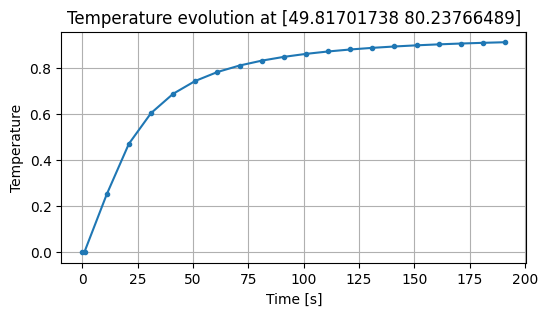

In [8]:
monitor_pt = np.array([0.5 * lx, 0.8 * ly])
monitor_node = int(np.argmin(np.linalg.norm(np.array(mesh.coords) - monitor_pt, axis=1)))
snapshot_times = np.array([0.0] + [(i * save_interval + 1) * dt for i in range(len(T_history)-1)])

monitor_T = np.array([float(T[monitor_node]) for T in T_history])

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(snapshot_times, monitor_T, marker='o', markersize=3)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Temperature")
ax.set_title(f"Temperature evolution at {mesh.coords[monitor_node]}")
ax.grid(True)
plt.show()

We create a animation to see the evolution of temperature in the plate.

In [ ]:
# [collapse: code] Code for creating an animation of the temperature distribution over time

from matplotlib.animation import FuncAnimation, PillowWriter

T_arr = [np.array(T) for T in T_history]
T_min, T_max = min(T.min() for T in T_arr), max(T.max() for T in T_arr)

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_aspect("equal")
tc = ax.tripcolor(
    mesh.coords[:, 0], mesh.coords[:, 1], mesh.elements, T_arr[0], 
    vmin=T_min, vmax=T_max, cmap="managua", shading="gouraud"
)
fig.colorbar(tc, label="Temperature")
title = ax.set_title(f"t = {snapshot_times[0]:.1f} s")

def animate(i):
    tc.set_array(T_arr[i])
    title.set_text(f"t = {snapshot_times[i]:.1f} s")
    return tc, title

anim = FuncAnimation(fig, animate, frames=len(T_history), blit=True, interval=100)
anim.save("heat_exchange.gif", writer=PillowWriter(fps=10))
plt.show()

![Heat transfer](../assets/images/heat_exchange.gif)